In [1]:
import torch
import pandas as pd

In [2]:
import sys
sys.path.append('../')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import common.utils as cutils    
import common.bounding_boxes as bboxes
import os
from common.dataset import BiopsiesCSVDataset, TestBiopsiesCSVDataset
from tqdm import tqdm

In [4]:
import timm
model = timm.create_model(
    'vit_huge_plus_patch16_dinov3_qkvb.lvd1689m',
    pretrained=True,
    num_classes=0,  # remove classifier nn.Linear
)
model = model.eval()
model = model.cuda()

def embedding(img, model=model):
    # get model specific transforms (normalization, resize)
    data_config = timm.data.resolve_model_data_config(model)
    transforms = timm.data.create_transform(**data_config, is_training=False)

    transformed = transforms(img)#.unsqueeze(0) if len(img.shape) < 4 else transforms(img)
    transformed = transformed.cuda()
    output = model(transformed)  # output is (batch_size, num_features) shaped tensor

    # or equivalently (without needing to set num_classes=0)

    output = model.forward_features(transforms(img))
    # output is unpooled, a (1, 261, 768) shaped tensor

    output = model.forward_head(output, pre_logits=True)
    return output


In [ ]:
df = pd.read_csv('../data/stella/test.csv')
# df['biopsy'].unique()
# df = df[df['biopsy']=='49_101-55.5_S3']
df.groupby('target').count()

array(['38_201-01.2_S1', '49_101-55.5_S2', '49_101-55.5_S4',
       '49_101-55.5_S1'], dtype=object)

In [7]:
def filter_df(df):
    mask = df['original_image'].isin(
        df.loc[df['target'] == 1, 'original_image'].unique()
    )

    filtered = df[mask]
    return filtered
    # filtered.groupby('target').count()


In [8]:
df['root_dir'] = '/lustre/home/dvrsnak/data/test_patches/'
dataset = BiopsiesCSVDataset(
    df,
    transform=None,
    target_transform=None,
    shared_transforms=None,
    preload=False,
    cache=False
)
img = dataset[0][0]

df2 = pd.read_csv('../data/stella/train.csv')
df2['root_dir'] = '/lustre/home/dvrsnak/data/stella/'
dataset2 = BiopsiesCSVDataset(
    df2,
    transform=None,
    target_transform=None,
    shared_transforms=None,
    preload=False,
    cache=False
)
img = dataset[0][0]

In [9]:
# img = torch.Tensor(dataset[0][0]).unsqueeze(0).repeat(3,1,1).unsqueeze(0)
# img = img.cuda()
# print(img.shape)
# emb = embedding(img)
# print(emb.shape)

In [10]:
def get_embeddings(dataset, bs=16):
    embs = []
    targets = []
    # i = 1000
    for i in tqdm(range(0, len(dataset), bs)):
        imgs = []
        for j in range(bs):
            if i + j >= len(dataset):
                break
            img = dataset[i + j]
            targets.append(img[1])
            img = torch.Tensor(img[0]).unsqueeze(0).repeat(3,1,1)
            imgs.append(img)

        imgs = torch.stack(imgs)
        imgs = imgs.cuda()
        # print(imgs.shape)
        
        emb = embedding(imgs)
        embs.append(emb.cpu().detach().numpy())
    return np.concatenate(embs, axis=0), targets

In [11]:
embs, targets = get_embeddings(dataset, bs=8)
embs_train, targets_train = get_embeddings(dataset2, bs=8)

  0%|          | 0/231 [00:00<?, ?it/s]

100%|██████████| 1434/1434 [24:11<00:00,  1.01s/it] 


In [12]:
len(targets_train)
targets = np.array(targets)
targets_train = np.array(targets_train)

In [13]:
sns.set_theme(style='white', context='notebook')


In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components=512)
embs_red_train = pca.fit_transform(embs_train)
embs_red = pca.transform(embs)
# import umap
# reducer = umap.UMAP(n_components=2)
# embs_red = reducer.fit_transform(embs)

from sklearn import svm
predictor = svm.LinearSVC()
predictor.fit(embs_red_train, targets_train)
preds_train = predictor.predict(embs_red_train)


In [16]:
acc = (preds_train == targets_train).sum() / len(targets_train)
print(f'Accuracy: {acc:.4f}')

preds = predictor.predict(embs_red)
acc = (preds == targets).sum() / len(targets)
print(f'Accuracy: {acc:.4f}')  

Accuracy: 0.9286
Accuracy: 0.7354


(1848, 1280)


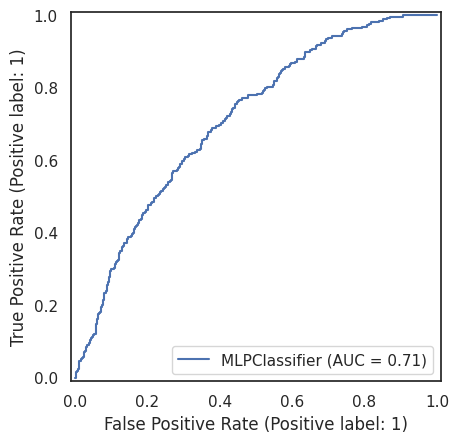

PCA components: 100000 - Train Accuracy: 0.9819
PCA components: 100000 - Test Accuracy: 0.7868
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      1590
           1       0.30      0.39      0.34       258

    accuracy                           0.79      1848
   macro avg       0.60      0.62      0.60      1848
weighted avg       0.81      0.79      0.80      1848



ValueError: x and y must have same first dimension, but have shapes (8,) and (1,)

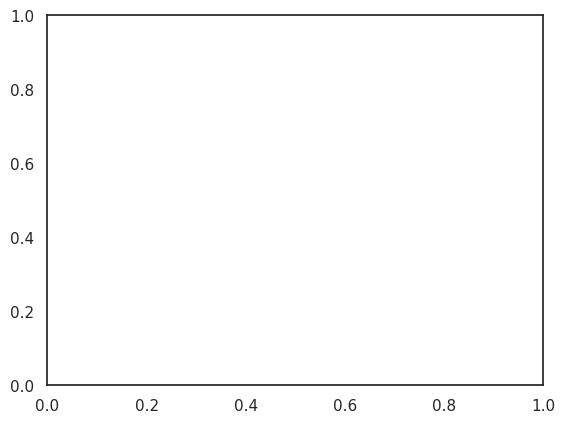

In [26]:
from sklearn.decomposition import PCA
from sklearn import svm
from sklearn import linear_model
from sklearn.discriminant_analysis import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, RocCurveDisplay
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
train_accs, accs = [], []
f1_scores = []
n_components = [10,20,100,200,300,500,1000,1024]
n_components = [100000]
for n in n_components:
    # scaler = StandardScaler()
    # embs_scaled_train = scaler.fit_transform(embs_train)
    # embs_scaled = scaler.transform(embs)
    if n > embs.shape[1]:
        embs_red_train = embs_train
        embs_red = embs
        print(embs_red.shape)
    else:
        pca = PCA(n_components=n)
        embs_red_train = pca.fit_transform(embs_train)
        embs_red = pca.transform(embs)

    class_weight = 'balanced'
    # predictor = make_pipeline(svm.LinearSVC(C=0.025))
    # predictor = RandomForestClassifier(max_depth=5, n_estimators=10, random_state=0)
    # predictor = linear_model.SGDClassifier(loss='log_loss', class_weight=class_weight, max_iter=1000)
    predictor = MLPClassifier(hidden_layer_sizes=(512, 128), max_iter=1000, early_stopping=True, warm_start=True)
    predictor.fit(embs_red_train, targets_train)
    preds_train = predictor.predict(embs_red_train)
    RocCurveDisplay.from_estimator(predictor, X=embs_red, y=targets)
    plt.show()

    acc = (preds_train == targets_train).sum() / len(targets_train)
    print(f'PCA components: {n} - Train Accuracy: {acc:.4f}')
    train_accs.append(acc)

    preds = predictor.predict(embs_red)
    acc = (preds == targets).sum() / len(targets)
    print(f'PCA components: {n} - Test Accuracy: {acc:.4f}')
    accs.append(acc)
    f1_scores.append(f1_score(targets, preds))
    print(classification_report(targets, preds))

plt.plot([10,20,100,200,300,500,1000,1024], train_accs, label='Train Accuracy')
plt.plot([10,20,100,200,300,500,1000,1024], accs, label='Test Accuracy')
plt.plot([10,20,100,200,300,500,1000,1024], f1_scores, label='F1 Score')
plt.xlabel('PCA components')
plt.ylabel('Accuracy')

plt.legend()
plt.show()


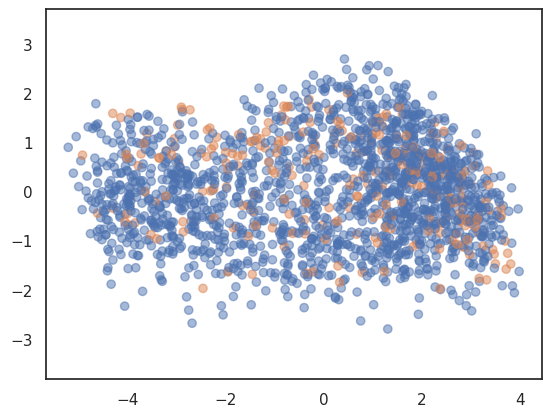

In [60]:
plt.scatter(
    embs_red[:, 0],
    embs_red[:, 1],
    c=[sns.color_palette()[x] for x in df['target']],
    # c=[sns.color_palette()[x] for x in preds],
    alpha=0.5,
    # c=[sns.color_palette()[biopsy_index[x]] for x in df['biopsy']],
    )
plt.gca().set_aspect('equal', 'datalim')

In [22]:
markers = ['o', 's', 'v', '^', '<', '>', '8', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X']
biopsy_index = {k:i for i,k in enumerate (df['biopsy'].unique())}
biopsy_index

{'38_201-01.2_S1': 0,
 '49_101-55.5_S2': 1,
 '49_101-55.5_S4': 2,
 '49_101-55.5_S1': 3}

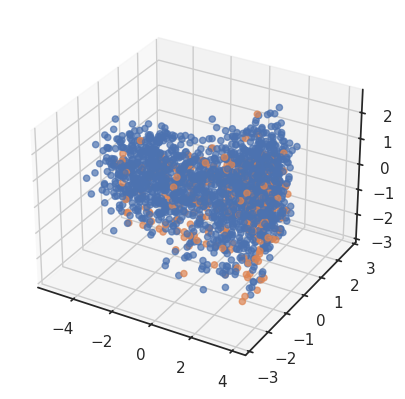

In [29]:

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(
    embs_red[:, 0],
    embs_red[:, 1],
    embs_red[:, 2],
    # c=[sns.color_palette()[biopsy_index[x]] for x in df['biopsy']],
    c=[sns.color_palette()[x] for x in df['target']],
    alpha=0.7,
    # marker=[markers[biopsy_index[x]] for x in df['biopsy']],
    # marker=markers[biopsy_index[df['biopsy'].iloc[i]]]
)

In [ ]:
df2 = pd.read_csv('../data/stella/test.csv')
df2 = df2[df2['biopsy']=='38_201-01.2_S1']
df2.groupby('target').count()

mask = df2['original_image'].isin(
    df2.loc[df2['target'] == 1, 'original_image'].unique()
)

# filtered = df2[mask]
# filtered.groupby('target').count()
# df2 = filtered


In [ ]:
df2['root_dir'] = '/lustre/home/dvrsnak/data/test_patches/'
dataset2 = BiopsiesCSVDataset(
    df2,
    transform=None,
    target_transform=None,
    shared_transforms=None,
    preload=False,
    cache=False
)
img = dataset2[0][0]

In [ ]:
embs2 = []
targets2 = []
i = 1000
for img in tqdm(dataset2):
    targets2.append(img[1])
    img = torch.Tensor(img[0]).unsqueeze(0).repeat(3,1,1)
    emb = embedding(img)
    embs2.append(emb.detach().numpy())
    i -= 1
    if i == 0:  
        break

In [ ]:
targets2 = np.array(targets2)
targets2.shape

In [ ]:
embs_red2 = reducer.transform(np.vstack(embs2))
embs_combined = np.concatenate([embs_red, embs_red2], axis=0)
targets_combined = np.concatenate([targets, targets2])
biopsy_label = ['o'] * len(embs_red) + ['x'] * len(embs_red2)

In [ ]:
reducer2 = umap.UMAP(n_components=3)
embs_red2_new = reducer2.fit_transform(np.vstack(embs2))

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(
    embs_red2_new[:, 0],
    embs_red2_new[:, 1],
    embs_red2_new[:, 2],
    c=[sns.color_palette()[x] for x in targets2],
)

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
c2 = np.concatenate([targets, [x + max(targets) + 1 for x in targets2]])

ax.scatter(
    embs_combined[:, 0],
    embs_combined[:, 1],
    embs_combined[:, 2],
    c=[sns.color_palette()[x] for x in c2],
)

In [ ]:
plt.scatter(
    embs_combined[:, 1],
    embs_combined[:, 2],
    c=[sns.color_palette()[x] for x in c2],
    )
plt.gca().set_aspect('equal', 'datalim')